In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/AAPL.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [2]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.dropna()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [4]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,3774,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,2016-07-01 03:40:32.432432,53.841169,54.383801,53.247465,53.801628,2.640640e+08
min,2009-01-02 00:00:00,2.345299,2.459265,2.345299,2.380989,2.404830e+07
25%,2012-09-28 18:00:00,15.050355,15.183043,14.901886,15.007580,9.581845e+07
50%,2016-06-30 12:00:00,26.975808,27.168844,26.836844,27.010205,1.667348e+08
75%,2020-03-31 18:00:00,74.664204,75.252383,73.553555,74.127927,3.777410e+08
max,2023-12-29 00:00:00,196.256592,197.752460,195.156944,196.167437,1.880998e+09
std,NaN,55.064042,55.627235,54.440128,55.009182,2.345629e+08


In [5]:
# moving average
#SMA
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
#EMA
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()


In [6]:
# RSI
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

In [7]:
# MACD
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

Visualization

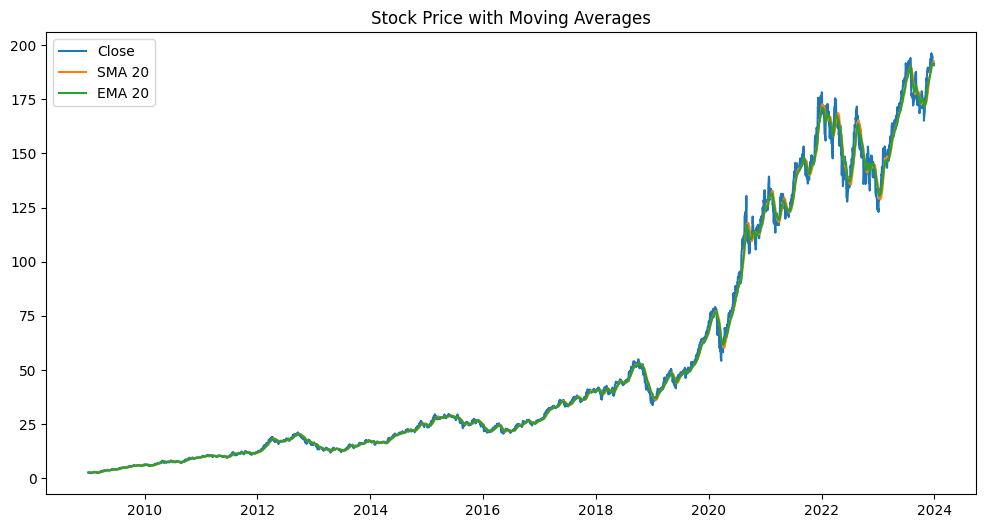

In [8]:
# Price and moving average

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

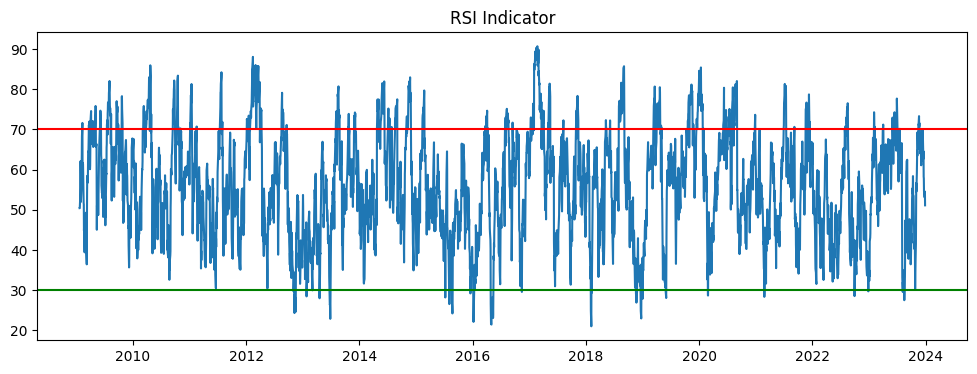

In [9]:
# RSI plot 
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['RSI'])

plt.axhline(70, color='red')
plt.axhline(30, color='green')

plt.title("RSI Indicator")
plt.show()

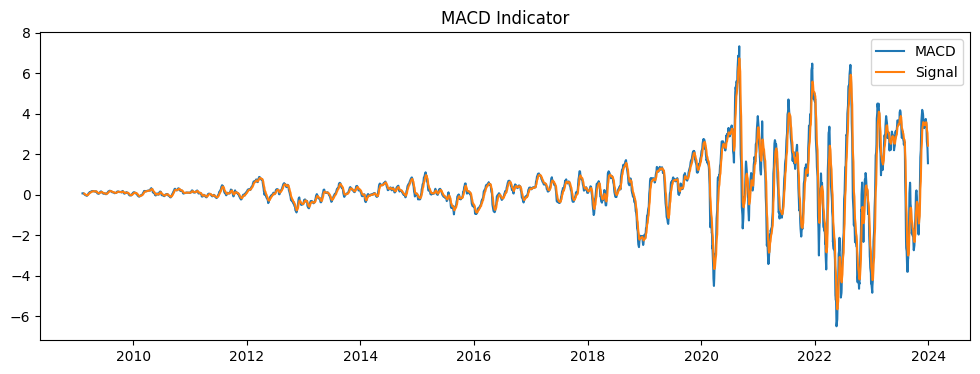

In [10]:
# MACD Plot
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal')

plt.legend()
plt.title("MACD Indicator")
plt.show()

PyNance was intended to be used for financial metric computation. Due to compatibility issues with pandas_datareader, equivalent financial indicators were computed manually using pandas and numpy. These include daily returns, rolling volatility (20-day window), log returns, and drawdown, which are standard outputs consistent with PyNance financial analysis functionality.

In [11]:

df['returns'] = df['Close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [12]:
df.tail()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,returns,volatility,log_returns
3769,2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,191.856618,183.572859,191.510231,54.672784,2.633141,3.235256,-0.005548,0.009071,-0.005563
3770,2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,192.018094,183.858864,191.484867,53.090049,2.304751,3.049155,-0.002841,0.009103,-0.002845
3771,2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,192.154308,184.149424,191.471353,53.354446,2.029104,2.845145,0.000518,0.009086,0.000518
3772,2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,192.362839,184.479567,191.499696,54.540999,1.823998,2.640915,0.002226,0.008973,0.002224
3773,2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,192.490633,184.814828,191.426275,51.121347,1.559539,2.424640,-0.005424,0.009078,-0.005439


In [13]:
df.to_csv("../data/AAPL_processed.csv")